# $\text{Taller - Regresión Lineal Simple}$
## $\text{Población histórica de Colombia 1950-2023}$

---

## **$\text{Tabla de contenido:}$**
0. $\text{Importar Librerías}$
1. $\text{Regresión Lineal Simple}$
2. $\text{Comprendiendo los Datos}$
3. $\text{Visualización de los Datos usando Gráficos}$
4. $\text{Realizando Regresión Lineal Simple}$
   - $\text{Preparación de X e y}$
   - $\text{División de los Datos en Conjuntos de Entrenamiento y Prueba}$
   - $\text{Realizando Regresión Lineal}$
5. $\text{Cálculo de Coeficientes}$
6. $\text{Predicciones}$
7. $\text{Evaluación del Modelo}$
6. $\text{Conclusiones}$

## $\text{0. Importar Librerías}$


In [ ]:
# Importar las librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## $\text{1. Regresión Lineal Simple}$
La regresión lineal simple es un modelo que busca relacionar dos variables de manera que podamos predecir el valor de una (dependiente) basándonos en la otra (independiente). En este caso, queremos predecir la **población** de Colombia en función de los **años**.

**Pregunta orientadora:** ¿Por qué crees que se elige una línea para ajustar los datos en lugar de otro tipo de curva?


**To Do**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## $\text{2. Comprendiendo los Datos}$

Cargue los datos desde el archivo proporcionado y realice una **limpieza** para eliminar cualquier información adicional que no sea útil para el análisis, incluyendo las **filas extra** en las celdas inicial y final del archivo.

In [ ]:
# Cargar datos y revisar la estructura inicial
data = pd.read_excel('/content/drive/MyDrive/UNAL/Semestre III/ML/Datas/Población.xlsx', skipfooter=3)

# Eliminar la primera fila después del encabezado
data = data.drop(index=0).reset_index(drop=True)

# Convierte la columna 'Fecha' a tipo datetime
data['Fecha'] = pd.to_datetime(data['Fecha'], errors='coerce')

# Luego, puedes extraer el año
data['Año'] = data['Fecha'].dt.year

data = data[['Año', 'Población']]  # Usar solo las columnas Año y Población

# Revisar las primeras filas para confirmar la limpieza
data.head()

,Año,Población
0,1950,13570943
1,1951,13912947
2,1952,14269792
3,1953,14641427
4,1954,15027963


**Pregunta orientadora:** ¿Qué importancia tiene eliminar los datos no deseados al inicio y al final del archivo?

## $\text{3. Visualización de los Datos usando Gráficos}$
Grafiquemos los datos para ver la tendencia de la población a lo largo de los años.

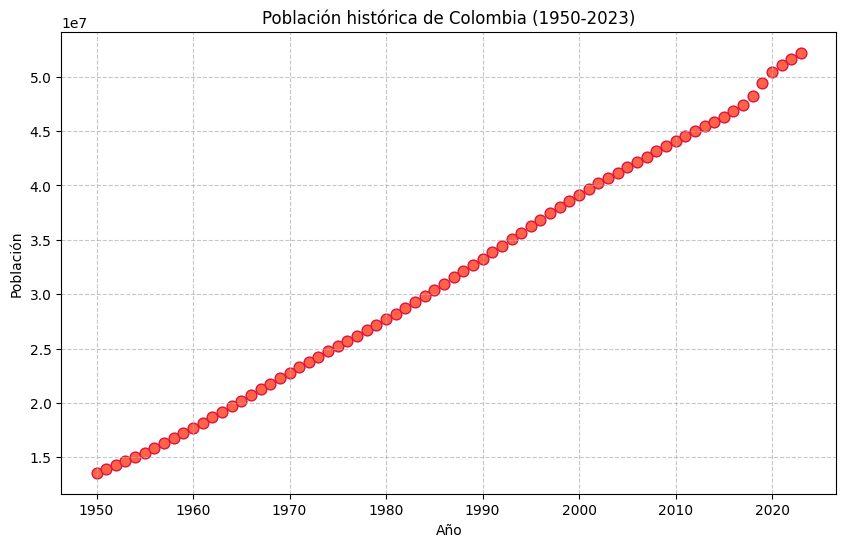

In [ ]:
# Crear gráfico de dispersión de Año vs Población
plt.figure(figsize=(10, 6))
plt.scatter(data['Año'], data['Población'], color='tomato', s = 60, edgecolors='crimson')
plt.xlabel('Año')
plt.ylabel('Población')
plt.title('Población histórica de Colombia (1950-2023)')
plt.grid(alpha = 0.7, linestyle = '--')
plt.show()


**Pregunta orientadora:** ¿Cómo describirías la relación entre el año y la población? ¿Parece una relación lineal?

**To Do**

## $\text{4. Realizando Regresión Lineal Simple}$



### **Preparación** de X e y
Para entrenar el modelo, definimos **X (años)** y ***y* (población).**

In [ ]:
data['Población'] = data['Población']/1000000

In [ ]:
# Separar las variables independientes (X) y dependientes (y)
X = data.iloc[:, :-1].values
y = data.iloc[:, 1].values
x_o = data.iloc[:, 0].values
print(X.shape, x_o.shape, y.shape)

(74, 1) (74,) (74,)


In [ ]:
type(X[0])

numpy.ndarray

In [ ]:
type(x_o[0])

numpy.int32

### **División** de los Datos en Conjuntos de Entrenamiento y Prueba
Divida los datos en un conjunto de entrenamiento y uno de prueba, lo cual es importante para evaluar la precisión del modelo.

In [ ]:
# Dividir el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)


**Pregunta orientativa:** ¿Por qué crees que se divide el dataset en entrenamiento y prueba? ¿Qué proporción utilizarías y por qué?

### Realizando Regresión Lineal
Entrene el modelo de regresión lineal simple.

In [ ]:
# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## $\text{5. Cálculo de Coeficientes}$
Una vez entrenado el modelo, obtenga los coeficientes $b_0$ (intercepto) y $b_1$ (pendiente).

In [ ]:
# Obtener los coeficientes
b0 = model.intercept_
b1 = model.coef_[0]
print(f"Intercepto (b0): {b0}")
print(f"Pendiente (b1): {b1}")


Intercepto (b0): -1025.5638280699507
Pendiente (b1): 0.5322126613110691


**Pregunta orientativa:** ¿Qué representa el valor de $b_1$ en términos del cambio poblacional? ¿Y qué significa $b_0$ en este contexto?


**To Do**

## $\text{6. Predicciones}$
Finalmente, use el modelo para hacer predicciones y visualicemos

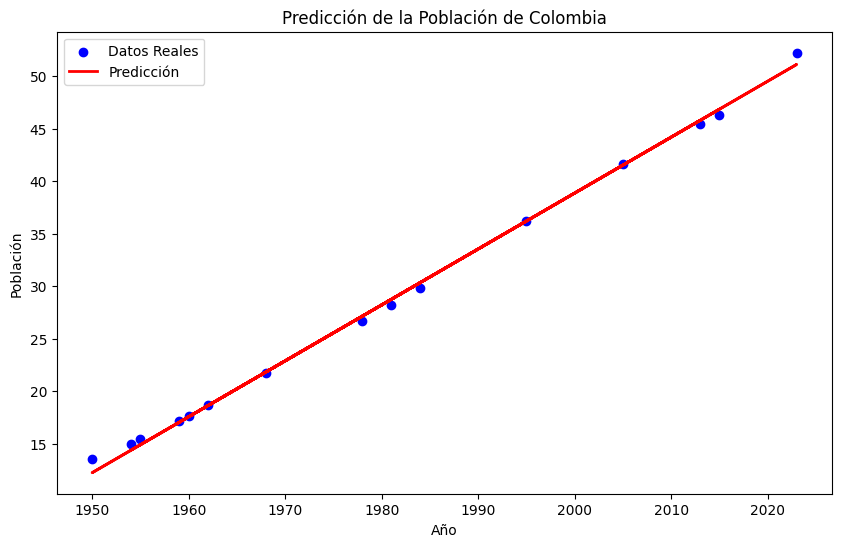

In [ ]:
# Realizar predicciones
y_pred = model.predict(X_test)

# Comparar predicciones con valores reales en el gráfico
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Datos Reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicción')
plt.xlabel('Año')
plt.ylabel('Población')
plt.title('Predicción de la Población de Colombia')
plt.legend()
plt.show()

Usa el modelo para predecir la población para los años **2024, 2030 y 2040**, y reflexiona sobre los cambios en la tendencia de crecimiento.

In [ ]:
# Predicciones para años futuros
años_futuros = np.array([[2024], [2030], [2040]])

# Realizar predicciones para los años 2024, 2030 y 2040
predicciones_futuras = model.predict(años_futuros)

# Mostrar las predicciones
print("\nPredicciones de población para años futuros:")
for año, poblacion in zip(años_futuros.flatten(), predicciones_futuras):
    print(f"Año {año}: {poblacion*1000000:.0f} personas")


Predicciones de población para años futuros:
Año 2024: 51634598 personas
Año 2030: 54827874 personas
Año 2040: 60150001 personas


## $\text{7. Evaluación del Modelo}$
Finalmente, evaluaremos el modelo usando métricas comunes en regresión, como el error cuadrático medio (MSE) y el coeficiente de determinación ($R^2$), que indican la precisión de nuestro modelo.

In [ ]:
# Calcular MSE y R^2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse}")
print(f"Coeficiente de determinación (R^2): {r2}")


Error cuadrático medio (MSE): 0.32767433805627405
Coeficiente de determinación (R^2): 0.9979241784246473


**Pregunta orientadora:** ¿Qué significa un $R^2$ cercano a 1 en este contexto?

## $\text{8. Conclusión}$
En este taller, exploraste cómo usar regresión lineal simple para predecir la población basada en el año. Reflexionaste sobre los coeficientes obtenidos y cómo la tendencia histórica puede ayudar a anticipar cambios futuros en la población de Colombia.

- **Pregunta orientativa:** ¿Qué otros factores podrías considerar para mejorar la precisión de la predicción de población, además del año?
- **Pregunta Final:** Basado en los resultados, ¿qué tan adecuado consideras el modelo de regresión lineal para este dataset de población histórica?

**To DO**